# Cortical TRF analysis 2: neural speech restoration at the cocktail party

This notebook redoes the six analyses from Brodbeck et al. 2020 (PLOS
Biology), "Neural speech restoration at the cocktail party", on this
project's own EEG dataset (13 subjects, binaural cocktail-party task)
instead of their original 26-subject MEG dataset.

**A note on expectations before you start:** this is a different dataset
(EEG, not MEG), a different, much smaller group (13 vs. 26 people), and a
different recording modality entirely. The point of this notebook is to
check whether the same *methodology* - the same predictors, the same
model comparisons, the same kinds of statistical tests - can be run on
this dataset and gives results that point the same direction as
Brodbeck's. It is not expected, and not required, to reproduce their
exact t-values, p-values, or peak-timing numbers. Brodbeck's numbers are
quoted throughout as a point of reference, not a target to hit.

**Renaming from `cortical_analysis.ipynb`:** that notebook calls the two
competing speakers "foreground" and "background". This notebook follows
Brodbeck's own terms instead: foreground -> **attend**, background ->
**ignore**, mixture stays **mix**. This is a renaming of variables,
labels, and plot titles only - the underlying data columns in
`experiment.py` (`ds['fg']`, `ds['bg']`, `ds['mix']`) are unchanged,
since `label_events()` is shared with the other notebook.

**Frequency resolution:** `cortical_analysis.ipynb` mostly uses the
1-band predictors (`gammatone-1`, `gammatone-on-1` - envelope/onsets
collapsed to one broadband number). This notebook uses the 8-band
versions (`gammatone-8`, `gammatone-on-8`) everywhere instead, so TRFs
can be examined separately per frequency band (an "STRF",
spectro-temporal response function) - matching how Brodbeck plots their
results.

## What happens, top to bottom

- Import eelbrain and `e` (same pipeline object as the other notebook -
  nothing about the raw EEG processing changes here).
- Preprocessing (bad channels, ICA) - identical cells to
  `cortical_analysis.ipynb`, safe to re-run (skips subjects already done).
- Shared setup: predictor-name helpers, labels/colors, the region of
  interest (ROI), and the `show_model_test`/model-comparison helpers
  reused across every analysis below.
- Analysis 1: onsets vs. envelope, single speaker and each two-talker
  condition (Brodbeck Fig 2).
- Analysis 2: does the brain track the ignored speaker too? (Fig 3)
- Analysis 3: attention's effect on envelope vs. onset responses.
- Analysis 4: overt vs. masked onsets (Fig 4).
- Analysis 5: masked-onset timing delay and the attention x masking
  interaction.
- Analysis 6: ruling out a simple loudness explanation for analysis 4/5.

Cells are meant to run top to bottom, in order - later cells reuse
variable names (`data`, `p`, `dss`, `roi_data`) from earlier ones, the
same way `cortical_analysis.ipynb` does.

In [1]:
from eelbrain import *
from experiment import e, FIGURES_DIR

# Where to save plots - inside the BIDS dataset's derivatives, same as
# cortical_analysis.ipynb, not somewhere outside the dataset.
DST = FIGURES_DIR

INFO    :  *** BinauralCocktail initialized with root /Users/joshuaighalo/Github Repositories/dataset/cocktail/bids on 2026-09-11 18:54:07 ***
INFO    :  Using eelbrain 0.0.0, mne 1.12.1.


## Preprocessing (run once per subject)

Identical to `cortical_analysis.ipynb` - both notebooks use the same
preprocessed EEG (`raw='ica'`), so this only does real work the first
time either notebook is run for a given subject. See the other
notebook's own preprocessing section for the full explanation of what
these two calls do and how the skip/redo prompting works.

In [2]:
MANUAL_BAD_CHANNELS = False
AUTO_BAD_CHANNELS_R = 0.3
REDO_BAD_CHANNELS = True

e.mark_bad_channels(
    'all',
    manual_bad_channels=MANUAL_BAD_CHANNELS, auto_bad_channels_r=AUTO_BAD_CHANNELS_R,
    redo_bad_channels=REDO_BAD_CHANNELS,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. Bad channels marked.


In [3]:
MANUAL_ICA = False
AUTO_ICA_CONFIDENCE = 0.75

e.select_ica_artifacts(
    'all',
    manual_ica=MANUAL_ICA, auto_ica_confidence=AUTO_ICA_CONFIDENCE,
)

  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. ICA fit and artifact components selected.


## Shared setup

Everything in this section is reused by every analysis below - defined
once here so each analysis section can stay focused on its own logic
instead of repeating boilerplate.

### Predictor-name helpers

Every predictor below is built from the same handful of pieces:
envelope or onset, attended/ignored/mixture, and (for analyses 4-6)
overt/masked/loudness-tier splits. Instead of typing out long model
strings by hand for every condition, these small functions build the
right string from a "stimulus role" prefix:

- `''` (empty prefix) = attended speaker (`fg` column - the default
  `stim_var` in `experiment.py`, no prefix needed)
- `'bg~'` = ignored speaker (reads the `bg` column instead)
- `'mix~'` = the acoustic mixture (reads the `mix` column)

This is exactly the mechanism `cortical_analysis.ipynb` already uses for
`bg~gammatone-on-1`/`mix~gammatone-on-1` - nothing new here, just
wrapped in functions so the analyses below don't repeat themselves.

The intensity-tier predictors from `predictors/gammatone_predictors.py`
are named `gammatone-on-low-8`/`-mid-8`/`-high-8` rather than
"mixture-onset-low" etc.: eelbrain only recognizes `gammatone` as a
registered predictor key (see `predictors` in `experiment.py`), so every
predictor code has to start with `gammatone-` to resolve at all. See the
comment above that block in `gammatone_predictors.py` for the full
explanation.

In [4]:
ATTEND, IGNORE, MIX = '', 'bg~', 'mix~'


def envelope(role=ATTEND):
    return f"{role}gammatone-8"


def onset(role=ATTEND):
    return f"{role}gammatone-on-8"


def overt_onset(role=ATTEND):
    return f"{role}gammatone-on-overt-8"


def masked_onset(role=ATTEND):
    return f"{role}gammatone-on-masked-8"


def level_onset(tier, role=MIX):
    assert tier in ('low', 'mid', 'high')
    return f"{role}gammatone-on-{tier}-8"


# The three two-talker listening conditions used throughout. "clean" (the
# single-speaker condition, used only in analysis 1) is handled on its own
# since it has no attend/ignore/mix split at all.
CONDITIONS = ['diotic', 'dichotic', 'binaural']

### Display names and colors

Human-readable labels and consistent colors for the three streams
(attend/ignore/mix), reused in every plot below - same idea as
`cortical_analysis.ipynb`'s `LABELS`/`COLORS`, adapted to the
attend/ignore renaming and to the 8-band predictor names (a `Dataset`
key turns `~`/`-` into `_`, so `bg~gammatone-on-8` becomes the column
name `bg_gammatone_on_8`).

In [5]:
LABELS = {
    'gammatone_on_8': 'Attend',
    'bg_gammatone_on_8': 'Ignore',
    'mix_gammatone_on_8': 'Mixture',
}
COLORS = {
    'gammatone_on_8': 'red',
    'bg_gammatone_on_8': 'blue',
    'mix_gammatone_on_8': '.3',
}

# Labels/colors for the overt/masked split (analyses 4 and 5).
LABELS_MASKING = {
    'gammatone_on_overt_8': 'Attend overt',
    'gammatone_on_masked_8': 'Attend masked',
    'bg_gammatone_on_overt_8': 'Ignore overt',
    'bg_gammatone_on_masked_8': 'Ignore masked',
}
COLORS_MASKING = {
    'gammatone_on_overt_8': 'firebrick',
    'gammatone_on_masked_8': 'red',
    'bg_gammatone_on_overt_8': 'darkblue',
    'bg_gammatone_on_masked_8': 'blue',
}

### Shared TRF-fitting settings and the `show_model_test` helper

`PARAMETERS` is identical to `cortical_analysis.ipynb`: which
preprocessed EEG to use, how many subjects, and the response time
window to fit. The boosting algorithm's own settings still live in
`experiment.py`'s `estimators`, not here.

`show_model_test` is copied unchanged from `cortical_analysis.ipynb` -
it stays available below for a quick whole-scalp-only look at several
comparisons at once. Every analysis in *this* notebook also wants the
ROI-restricted t/p Brodbeck reports alongside the topomap, so the
`unique_contribution`/`direct_comparison` helpers further down wrap the
same two lines you see here (`load_model_test` then `plot.Topomap`) and
add that ROI step, rather than calling `load_model_test` a second time
for the same comparison.

In [6]:
PARAMETERS = {
    'raw': 'ica',
    'group': 'all',
    'samplingrate': 128,
    'data': 'eeg',
    'tstart': -0.100,
    'tstop': 0.600,
}


def show_model_test(comparisons, vmax=None, **kwargs):
    for label, comparison in comparisons.items():
        result = e.load_model_test(comparison, **kwargs)
        display(plot.Topomap(result, vmax=vmax, title=label))

### Region of interest (ROI)

Reusing the exact same fronto-central ROI as `cortical_analysis.ipynb`
(not inventing a new one) - cortical speech responses are usually
strongest there, so the analyses below average over this sensor set
instead of showing every electrode separately.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


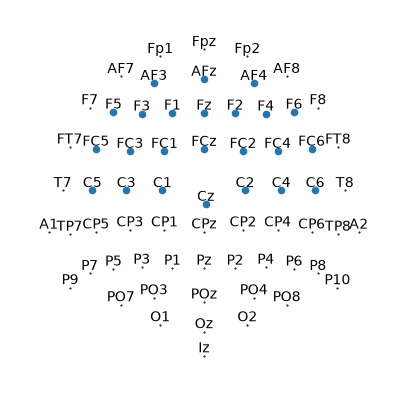

In [7]:
data = e.load_trfs(1, 'gammatone-8', epoch='clean', **PARAMETERS)
eeg = data['ev']

ROI = [
    'AF3', 'F1', 'F3', 'F5',
    'FC5', 'FC3', 'FC1',
    'C1', 'C3', 'C5',
    'AF4', 'AFz',
    'Fz', 'F2', 'F4', 'F6',
    'FC6', 'FC4', 'FC2', 'FCz',
    'Cz', 'C2', 'C4', 'C6',
]

p = plot.SensorMap(eeg, mark=ROI)

### Unique-contribution and direct model-comparison helpers

Two kinds of model comparison are used throughout this notebook (see
`e.load_model_test`'s own docstring for the underlying syntax):

- **`full_model @ predictor`** - omission comparison: fits `full_model`,
  then a null model with just `predictor` removed, and tests whether
  `predictor` uniquely improves the fit. This is what
  `cortical_analysis.ipynb` already uses.
- **`model_a > model_b`** - *direct* comparison between two
  independently-specified models (not one nested inside the other by
  removing a single term). This is what analyses 4 and 6 need: they
  compare two models built from genuinely different predictor sets, not
  "the same model minus one predictor". eelbrain supports this directly
  in the model-string grammar (`load_model_test`'s docstring gives
  `'acoustic + lexical > acoustic'` as an example) - no separate API
  needed.

Both helpers below do the same three things: run the comparison, show a
whole-scalp topomap of where it is significant, then reduce to the ROI
and report a single t/p pair (a one-sample, one-tailed t-test of the
per-subject ROI-averaged score-improvement against zero - equivalent to
a paired t-test of "test" against "baseline", since the improvement
*is* that pairwise difference already worked out per subject).

In [8]:
def _roi_ttest(data, roi=ROI, tail=1):
    data = table.difference('ev', 'model', 'test', 'baseline', 'subject', data=data)
    data['roi_ev'] = data['ev'].mean(sensor=roi)
    return data, test.TTestOneSample('roi_ev', data=data, tail=tail)


def unique_contribution(full_model, predictor, epoch, label=None, vmax=.0005, roi=ROI):
    "Whole-scalp + ROI test of one predictor's unique contribution to `full_model`"
    comparison = f"{full_model} @ {predictor}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=0.05, metric='ev', epoch=epoch, return_data=True)
    display(plot.Topomap(result, vmax=vmax, title=label or f"{predictor} ({epoch})"))
    data, ttest = _roi_ttest(data, roi)
    print(f"{epoch} | unique contribution of {predictor}: ROI t({ttest.df}) = {ttest.t:.2f}, p = {ttest.p:.4f}")
    return data, ttest


def direct_comparison(model_a, model_b, epoch, label=None, vmax=.0005, roi=ROI):
    "Whole-scalp + ROI test of whether model_a fits better than model_b (a genuine two-model comparison)"
    comparison = f"{model_a} > {model_b}"
    data, result = e.load_model_test(comparison, **PARAMETERS, pmin=0.05, metric='ev', epoch=epoch, return_data=True)
    display(plot.Topomap(result, vmax=vmax, title=label or f"model comparison ({epoch})"))
    data, ttest = _roi_ttest(data, roi)
    print(f"{epoch} | model_a fits better: ROI t({ttest.df}) = {ttest.t:.2f}, p = {ttest.p:.4f}")
    return data, ttest


def roi_strf(predictor_model, predictor_column, epoch, roi=ROI):
    "Group-average (frequency, time) STRF for one predictor, averaged over the ROI and over subjects"
    data = e.load_trfs('all', predictor_model, epoch=epoch, **PARAMETERS)
    return data[predictor_column].mean(sensor=roi).mean('case')

## Analysis 1: onsets vs. envelope (Brodbeck Fig 2)

**Question:** does the brain track sudden onsets (the start of a word or
syllable) as something distinct from the moment-to-moment loudness
envelope, or is one just a byproduct of the other? Brodbeck et al. found
both matter and have very different response shapes, with onsets giving
a much stronger, more sharply timed response.

**Why this test:** the standard way to ask "does predictor X help
explain the brain response, above and beyond everything else in the
model" is to fit a full model with X included, fit the same model with
X removed (the null model), and test whether the full model predicts
left-out brain data better. Doing that separately for onsets and for
envelope, in the single-speaker condition first, checks whether either
one matters on its own before any competing-speaker complexity is added.

This is run once for the single-speaker ("clean") condition, and once
per stream (attend/ignore/mix) in each of the three two-talker
conditions - the ignore/mix streams aren't part of Brodbeck's own
analysis 1, but including them here previews the raw ingredients that
analysis 2 will combine.

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

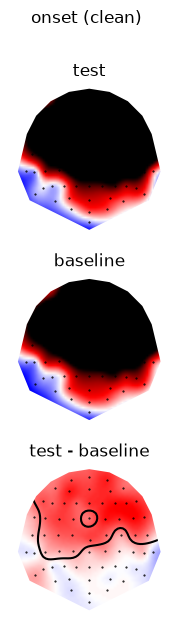

clean | unique contribution of gammatone-on-8: ROI t(12) = 2.79, p = 0.0082


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

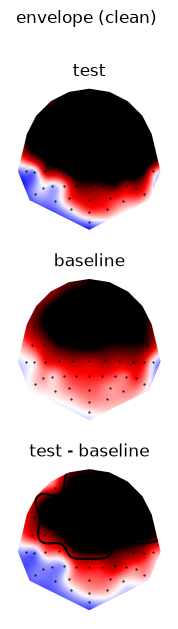

clean | unique contribution of gammatone-8: ROI t(12) = 2.81, p = 0.0078


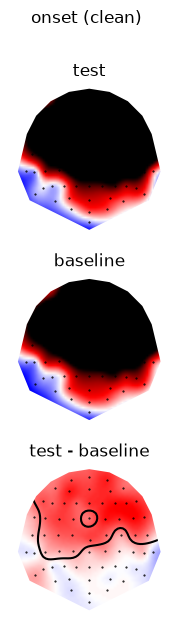

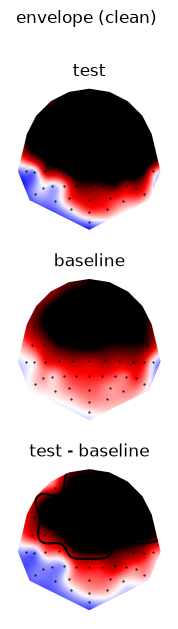

In [9]:
# Single speaker (clean): the simplest case, no competing talker at all.
# unique_contribution() already gives both pieces the paper reports here
# in one call: a whole-scalp topomap (is this predictor significant
# anywhere on the head) and a ROI-restricted t/p (is it significant in
# the auditory region of interest specifically).
full_model_clean = f"{envelope(ATTEND)} + {onset(ATTEND)}"
for predictor_key, predictor in (('onset', onset(ATTEND)), ('envelope', envelope(ATTEND))):
    unique_contribution(full_model_clean, predictor, epoch='clean', label=f"{predictor_key} (clean)", vmax=.001)

Brodbeck's single-speaker result: onsets t = 12.00, envelope t = 9.39
(both p <= .001), both strongest over Heschl's gyrus/superior temporal
gyrus. The ROI t/p values printed above are this dataset's equivalent
comparison - a much smaller group (13 vs. 26 subjects) and a coarser
sensor-space (not source-localized) measurement, so smaller or noisier
t-values here don't contradict Brodbeck's finding, they're just a
lower-powered version of the same test.

Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

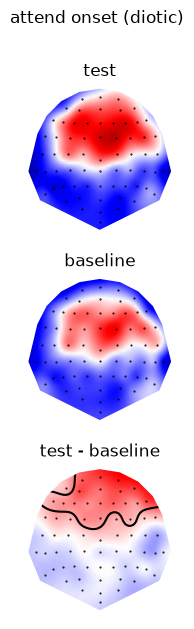

diotic | unique contribution of gammatone-on-8: ROI t(12) = 3.07, p = 0.0049


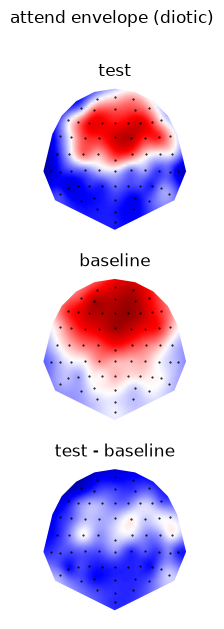

diotic | unique contribution of gammatone-8: ROI t(12) = -0.88, p = 0.8008


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

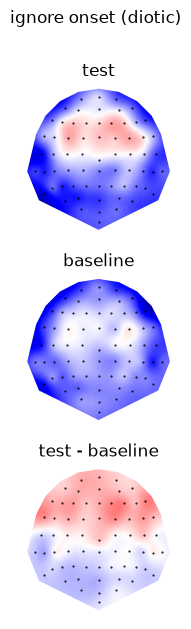

diotic | unique contribution of bg~gammatone-on-8: ROI t(12) = 1.50, p = 0.0798


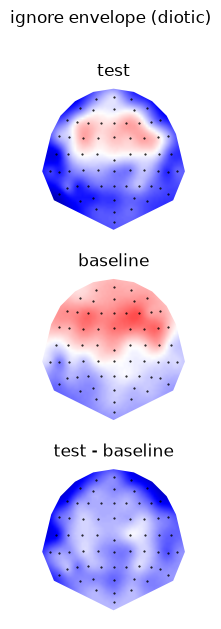

diotic | unique contribution of bg~gammatone-8: ROI t(12) = -1.78, p = 0.9499


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

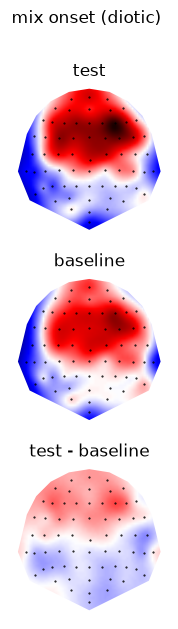

diotic | unique contribution of mix~gammatone-on-8: ROI t(12) = 1.44, p = 0.0873


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

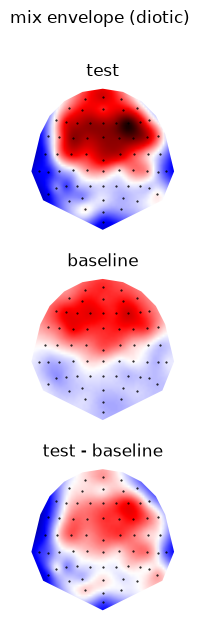

diotic | unique contribution of mix~gammatone-8: ROI t(12) = 1.33, p = 0.1048


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

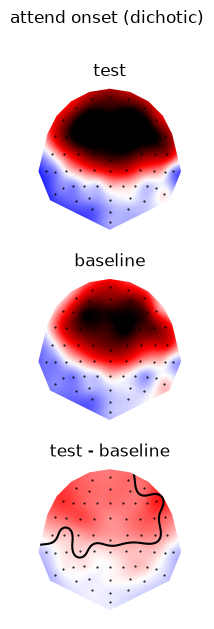

dichotic | unique contribution of gammatone-on-8: ROI t(12) = 2.95, p = 0.0060


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

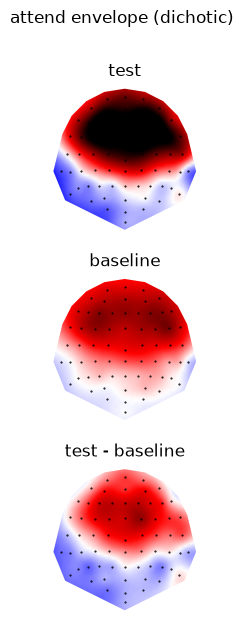

dichotic | unique contribution of gammatone-8: ROI t(12) = 1.71, p = 0.0562


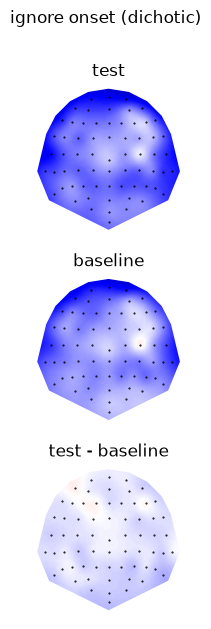

dichotic | unique contribution of bg~gammatone-on-8: ROI t(12) = -1.56, p = 0.9278


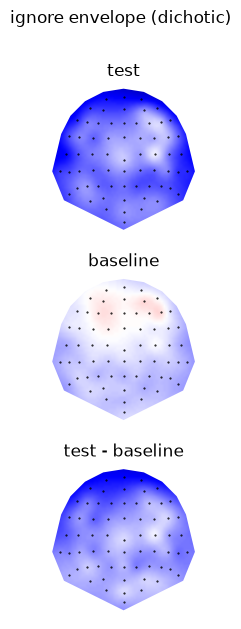

dichotic | unique contribution of bg~gammatone-8: ROI t(12) = -2.68, p = 0.9899


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

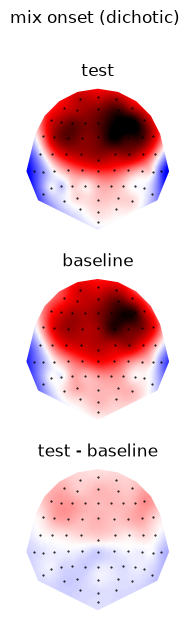

dichotic | unique contribution of mix~gammatone-on-8: ROI t(12) = 1.68, p = 0.0596


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

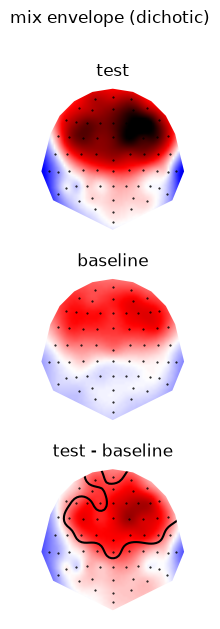

dichotic | unique contribution of mix~gammatone-8: ROI t(12) = 2.85, p = 0.0073


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

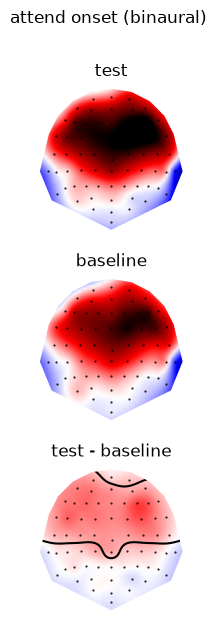

binaural | unique contribution of gammatone-on-8: ROI t(12) = 3.08, p = 0.0048


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

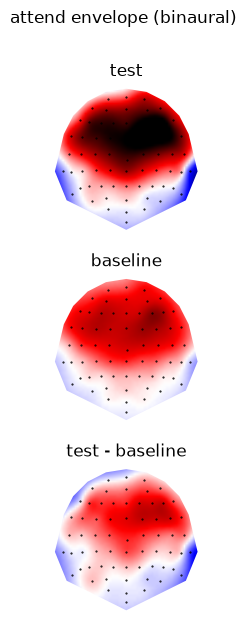

binaural | unique contribution of gammatone-8: ROI t(12) = 1.62, p = 0.0659


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

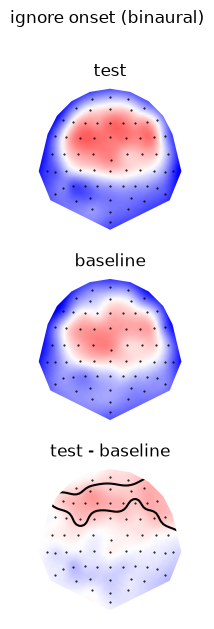

binaural | unique contribution of bg~gammatone-on-8: ROI t(12) = 2.07, p = 0.0301


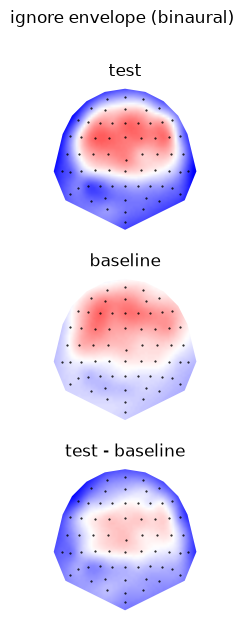

binaural | unique contribution of bg~gammatone-8: ROI t(12) = -0.00, p = 0.5007


Permutation test:   0%|          | 0/8191 [00:00<?, ? permutations/s]

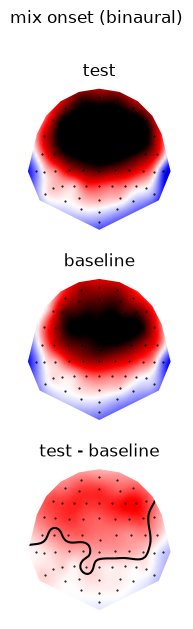

binaural | unique contribution of mix~gammatone-on-8: ROI t(12) = 2.59, p = 0.0117


KeyboardInterrupt: 

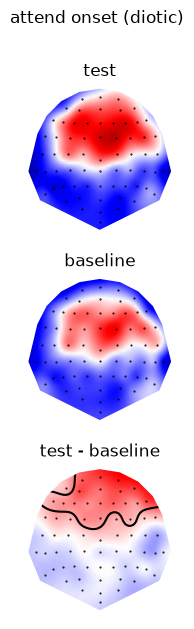

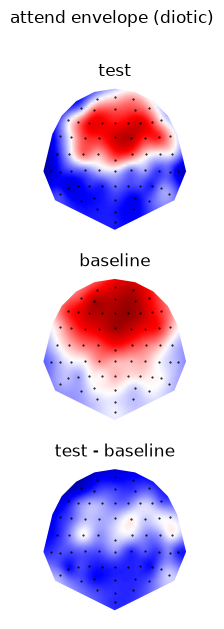

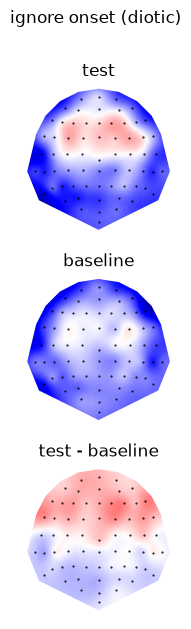

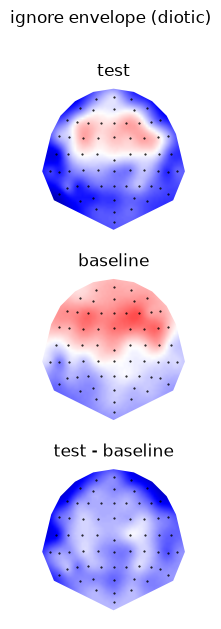

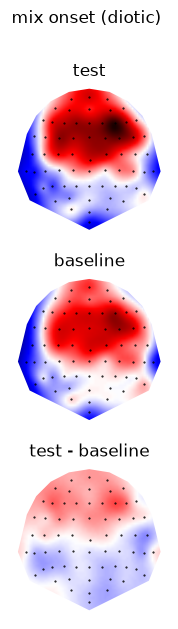

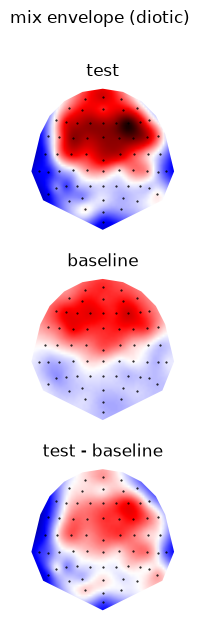

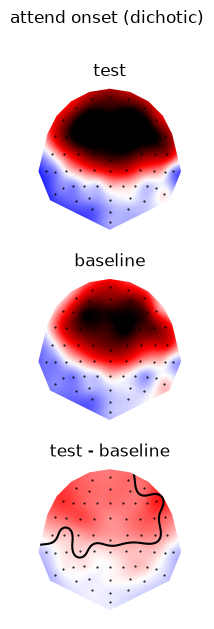

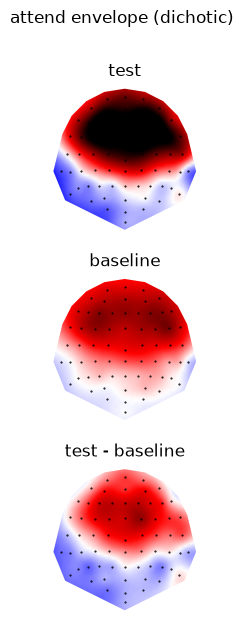

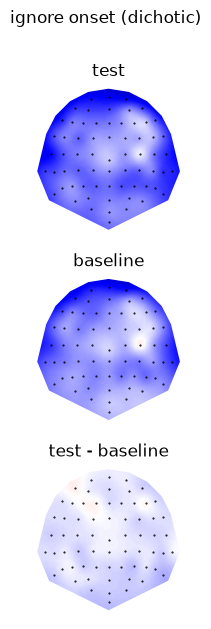

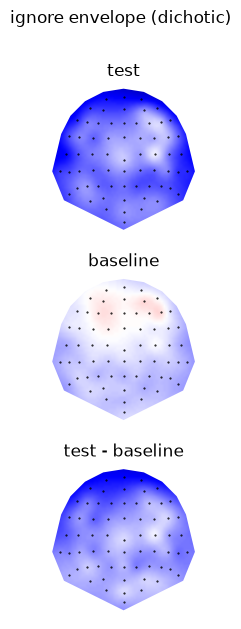

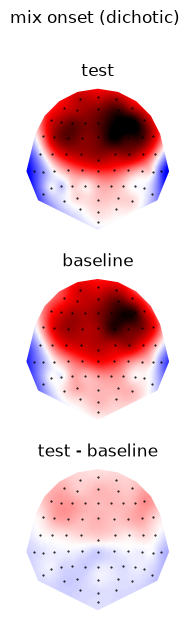

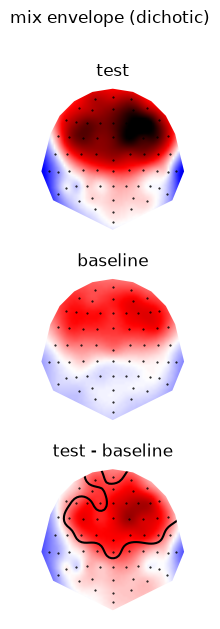

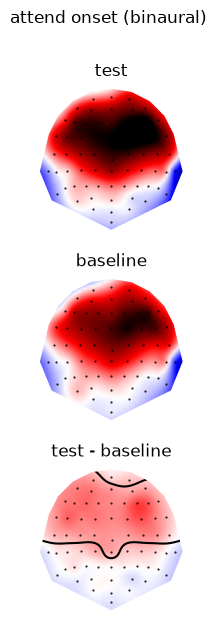

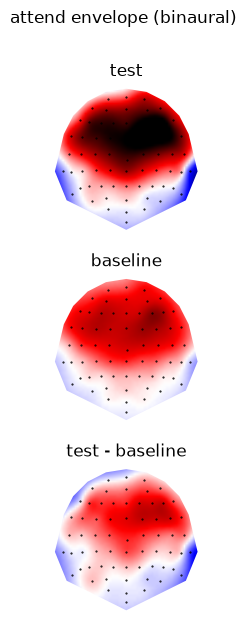

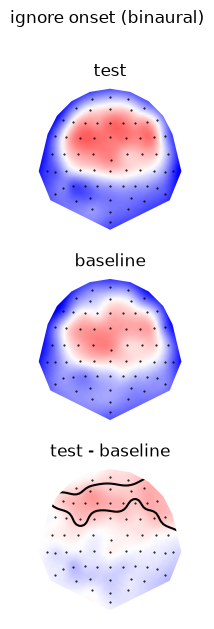

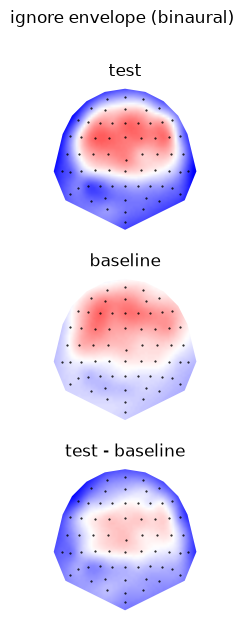

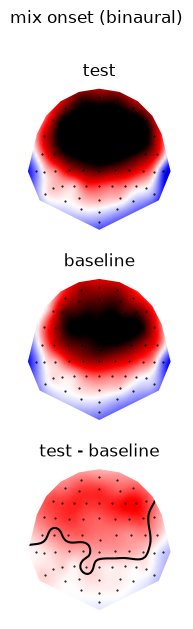

In [10]:
# Same onset-vs-envelope test, now separately for each stream
# (attend/ignore/mix) in each two-talker condition.
for epoch in CONDITIONS:
    for role_name, role in (('attend', ATTEND), ('ignore', IGNORE), ('mix', MIX)):
        full_model = f"{envelope(role)} + {onset(role)}"
        for predictor_key, predictor in (('onset', onset(role)), ('envelope', envelope(role))):
            unique_contribution(full_model, predictor, epoch=epoch, label=f"{role_name} {predictor_key} ({epoch})", vmax=.001)

### STRF shape: onset vs. envelope response, by frequency band

Brodbeck's onset STRF has a clear two-bump shape (positive peak at about
65ms, negative peak at about 126ms), stronger in lower frequency bands;
the envelope STRF is weaker and less clearly shaped. Plotting the
8-band STRF directly (frequency on the y-axis, time on the x-axis, color
= response strength) is the same kind of plot as Brodbeck's Fig 2,
instead of the single collapsed time series `cortical_analysis.ipynb`
plots for the 1-band predictors.

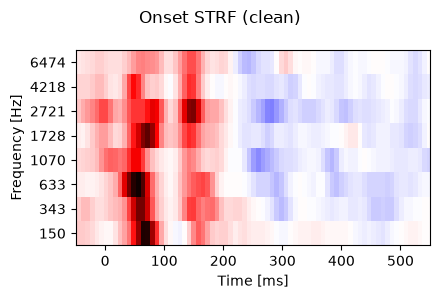

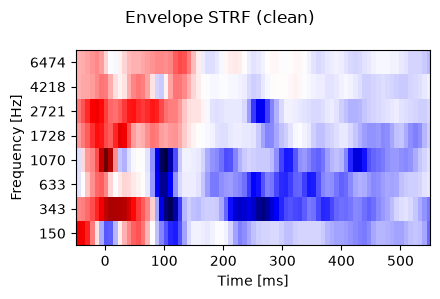

In [11]:
strf_onset = roi_strf(f"{envelope(ATTEND)} + {onset(ATTEND)}", 'gammatone_on_8', epoch='clean')
strf_envelope = roi_strf(f"{envelope(ATTEND)} + {onset(ATTEND)}", 'gammatone_8', epoch='clean')

p = plot.Array(strf_onset * 1e3, title='Onset STRF (clean)', xlim=(-0.050, 0.550))
p = plot.Array(strf_envelope * 1e3, title='Envelope STRF (clean)', xlim=(-0.050, 0.550))

### Onset peak timing

Extracts, for each subject, the time of the largest positive response
(20-130ms window, matching Brodbeck's ~65ms positive peak) and the
largest negative response (100-200ms window, matching their ~126ms
negative peak) in the ROI-averaged, broadband-summed onset TRF, then
reports the group mean - the same-style comparison as
`cortical_analysis.ipynb`'s "Peak response time" section, just for both
peaks of the two-bump onset shape instead of one.

Positive peak: mean 81 ms (Brodbeck: ~65 ms)
Negative peak: mean 135 ms (Brodbeck: ~126 ms)


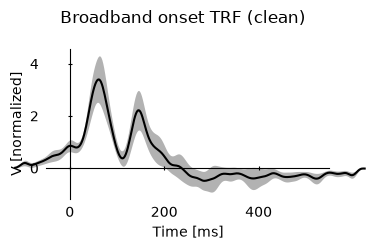

In [12]:
data = e.load_trfs(-1, onset(ATTEND), epoch='clean', **PARAMETERS)
trf = data['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
trf_sm = resample(trf, 512)

positive_peak_time = trf_sm.sub(time=(0.020, 0.130)).argmax('time')
negative_peak_time = trf_sm.sub(time=(0.080, 0.200)).argmin('time')
print(f"Positive peak: mean {positive_peak_time.mean() * 1e3:.0f} ms (Brodbeck: ~65 ms)")
print(f"Negative peak: mean {negative_peak_time.mean() * 1e3:.0f} ms (Brodbeck: ~126 ms)")

p = plot.UTSStat(trf_sm * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title='Broadband onset TRF (clean)')

## Analysis 2: does the brain track the ignored speaker too? (Brodbeck Fig 3)

**Question:** once the mixture and the attended speaker are already in
the model, does adding the *ignored* speaker's onsets/envelope as its
own predictor still improve the fit? If yes, that means the brain has
separated the ignored voice out of the combined sound, not just
processed "whatever's loud in the mixture".

**Why this test:** same unique-contribution logic as analysis 1, but
now with all three streams (mixture, attend, ignore) fit together in one
6-predictor model, so each stream's contribution is measured *after*
the other two already had a chance to explain the response.

In [ ]:
FULL_ANALYSIS2 = f"{envelope(ATTEND)} + {onset(ATTEND)} + {envelope(IGNORE)} + {onset(IGNORE)} + {envelope(MIX)} + {onset(MIX)}"

STREAM_PREDICTORS = {
    'attend_onset': onset(ATTEND), 'attend_envelope': envelope(ATTEND),
    'ignore_onset': onset(IGNORE), 'ignore_envelope': envelope(IGNORE),
    'mix_onset': onset(MIX), 'mix_envelope': envelope(MIX),
}

for epoch in CONDITIONS:
    print(f"--- {epoch} ---")
    for label, predictor in STREAM_PREDICTORS.items():
        unique_contribution(FULL_ANALYSIS2, predictor, epoch=epoch, label=f"{label} ({epoch})")

Brodbeck's reference values (their two-talker condition, source space):
ignored onsets t = 6.70, ignored envelope t = 6.28 (both p < .001) -
both reliably above zero despite the ignored speaker never being the
one the listener was told to attend to. For comparison: mixture onsets
t = 8.61, mixture envelope t = 5.70, attended onsets t = 6.32, attended
envelope t = 7.37. The key comparison to check in the numbers above is
not whether this dataset's t-values match those exactly, but whether
`ignore_onset`/`ignore_envelope` come out reliably positive (p < .05) in
at least some of diotic/dichotic/binaural here too.

### STRF peak timing: mixture vs. attended vs. ignored onsets

Brodbeck report the mixture's onset response peaks earliest and
largest, with the attended and ignored streams' responses arriving
progressively later - the "cost" of pulling one voice out of a mixture.
This repeats `cortical_analysis.ipynb`'s TRF/peak-timing section, now
for the renamed attend/ignore/mix streams, across all three conditions.

In [ ]:
PLOT_ARGS = dict(frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), clip=True, top=2.5, bottom=-0.5)
all_dss = []
legend = True
for epoch in CONDITIONS:
    data = e.load_trfs(-1, FULL_ANALYSIS2, epoch=epoch, **PARAMETERS)

    dss = []
    for x in data.info['xs']:
        if '_on' not in x:
            continue  # keep only the onset-response predictors
        ds = data['subject',]
        ds[:, 'x'] = x
        ds[:, 'epoch'] = epoch
        ds['trf'] = data[x].sum('frequency').mean(sensor=ROI)
        dss.append(ds)
        all_dss.append(ds)
    roi_data = combine(dss)
    p = plot.UTSStat('trf*1e3', 'x', data=roi_data, title=epoch.capitalize(), **PLOT_ARGS, labels=LABELS, colors=COLORS, legend=legend)
    p.save(DST / f'task-cocktail_epoch-{epoch}_desc-attendignoremix-trf_uts.png', dpi=300)
    legend = False

roi_data = combine(all_dss)
roi_data['trf_sm'] = resample(roi_data['trf'], 512)

In [ ]:
# Early positive peak (~70-90ms window) and late negative peak (~130-180ms
# window), matching the windows Brodbeck report their two peaks in.
roi_data['positive_peak'] = roi_data['trf_sm'].sub(time=(0.020, 0.130)).argmax('time')
roi_data['negative_peak'] = roi_data['trf_sm'].sub(time=(0.100, 0.200)).argmin('time')
roi_data['positive_amp'] = roi_data['trf_sm'].sub(time=(0.020, 0.130)).max('time')

for epoch in CONDITIONS:
    display(test.pairwise('positive_peak', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, corr=False, title=f'positive peak latency ({epoch})'))
    display(test.pairwise('negative_peak', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, corr=False, title=f'negative peak latency ({epoch})'))
    display(test.pairwise('positive_amp', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, corr=False, title=f'positive peak amplitude ({epoch})'))
    p = plot.Barplot('positive_peak', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, h=2, w=2.5, labels=LABELS, title=epoch, corr=False)
    p.set_xtick_rotation(30)

Brodbeck's numbers for reference: positive peak latency mixture 72ms,
attended 81ms (t = 4.47, p < .001), ignored 89ms (t = 6.92, p < .001);
negative peak latency mixture 138ms, attended 150ms (t = 3.20, p =
.004), barely present for the ignored stream; positive peak amplitude
bigger for mixture than attended (t = 8.41) or ignored (t = 7.66);
negative peak amplitude not reliably different between attended and
mixture (t = 1.56, p = .132). The expected pattern here: mixture peaks
earliest, attended next, ignored latest.

## Analysis 3: envelope and onset attention effects (attended minus ignored)

**Question:** when does the brain's response start to depend on
*attention* (attended vs. ignored), rather than just on the acoustics?
Brodbeck found the envelope response splits by attention almost
immediately, while the onset response's attention effect appears later
and is shaped differently.

**Why a difference wave, not a formal stat test:** this is a
descriptive comparison, matching Brodbeck's own analysis 3 (they don't
report a formal significance test here either) - subtracting the
ignored-speaker TRF from the attended-speaker TRF and looking at where
the resulting curve departs from zero and how it's shaped.

In [ ]:
for epoch in CONDITIONS:
    data = e.load_trfs(-1, FULL_ANALYSIS2, epoch=epoch, **PARAMETERS)

    envelope_attend = data['gammatone_8'].sum('frequency').mean(sensor=ROI)
    envelope_ignore = data['bg_gammatone_8'].sum('frequency').mean(sensor=ROI)
    onset_attend = data['gammatone_on_8'].sum('frequency').mean(sensor=ROI)
    onset_ignore = data['bg_gammatone_on_8'].sum('frequency').mean(sensor=ROI)

    envelope_effect = envelope_attend - envelope_ignore
    onset_effect = onset_attend - onset_ignore

    p = plot.UTSStat(envelope_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title=f'Envelope attention effect: attend - ignore ({epoch})')
    p = plot.UTSStat(onset_effect * 1e3, frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), title=f'Onset attention effect: attend - ignore ({epoch})')

Brodbeck's envelope difference wave: a negative bump around 100ms, a
positive bump around 200ms, starting almost immediately after sound
onset. Onsets, by contrast, only start to show an attention effect once
the later (masked-onset) response kicks in - see analysis 5. Look at
the shape and rough timing of the curves above, not an exact numeric
match.

## Analysis 4: overt vs. masked onsets (Brodbeck Fig 4)

**Question:** does the brain treat an onset that's still audible in the
mixture ("overt") differently from one that got physically buried under
the other speaker at that instant ("masked")? If the brain only
describes the physical mixture, both should look the same; if it
actively reconstructs missing information, masked onsets should behave
differently.

**The new predictors** (`predictors/gammatone_predictors.py`, "Block
1"): for the attended and ignored speaker separately,
`masked = max(source onset - mixture onset, 0)`,
`overt = min(mixture onset, source onset)`. This replaces the plain
`gammatone-on-8` predictor for each speaker with two more detailed ones.

**Why a direct two-model comparison, not `@`:** the question here isn't
"does removing one predictor from the analysis-2 model hurt the fit"
(that's what `@` tests) - it's "does *replacing* the attended/ignored
onset predictors with the overt/masked split improve the fit over the
analysis-2 model". Those are two separately-built, non-nested models
(the masked/overt model doesn't contain the analysis-2 model as a
subset, or vice versa), which is exactly what `load_model_test`'s
`model_a > model_b` direct-comparison syntax is for (see the
`direct_comparison` helper defined in the shared setup above).

In [ ]:
FULL_ANALYSIS4 = (
    f"{envelope(ATTEND)} + {overt_onset(ATTEND)} + {masked_onset(ATTEND)} + "
    f"{envelope(IGNORE)} + {overt_onset(IGNORE)} + {masked_onset(IGNORE)} + "
    f"{envelope(MIX)} + {onset(MIX)}"
)

for epoch in CONDITIONS:
    print(f"--- {epoch}: does the overt/masked split improve on the plain onset model? ---")
    direct_comparison(FULL_ANALYSIS4, FULL_ANALYSIS2, epoch=epoch, label=f"overt/masked vs. plain onsets ({epoch})")

Brodbeck's overall model-improvement result: t = 6.81, p < .001.

In [ ]:
MASKING_PREDICTORS = {
    'attend_overt': overt_onset(ATTEND), 'attend_masked': masked_onset(ATTEND),
    'ignore_overt': overt_onset(IGNORE), 'ignore_masked': masked_onset(IGNORE),
}

for epoch in CONDITIONS:
    print(f"--- {epoch}: unique contribution of each of the 4 new predictors ---")
    for label, predictor in MASKING_PREDICTORS.items():
        unique_contribution(FULL_ANALYSIS4, predictor, epoch=epoch, label=f"{label} ({epoch})")

Brodbeck's per-predictor results: attended masked t = 8.42 (p < .001),
ignored masked t = 5.23 (p < .001), attended overt t = 3.34 (p = .027),
ignored overt t = 3.82 (p = .016) - masked onsets driving a stronger
response than overt ones for both streams.

### STRF plots for all four predictors, by frequency band (matching Fig 4)

In [ ]:
for epoch in CONDITIONS:
    for column, label in (('gammatone_on_overt_8', 'Attend overt'), ('gammatone_on_masked_8', 'Attend masked'),
                           ('bg_gammatone_on_overt_8', 'Ignore overt'), ('bg_gammatone_on_masked_8', 'Ignore masked')):
        strf = roi_strf(FULL_ANALYSIS4, column, epoch=epoch)
        p = plot.Array(strf * 1e3, title=f"{label} ({epoch})", xlim=(-0.050, 0.550))

## Analysis 5: masked-onset delay and the stream x masking interaction

**Part A - timing:** does "unmasking" a hidden onset cost the brain
extra processing time, compared to an onset that was already visible in
the mixture? Same peak-latency comparison logic as analysis 2, applied
to overt vs. masked instead of mixture vs. attended vs. ignored - a
wider time window is used here since masked onsets are expected to peak
later.

**Part B - does attention affect masked onsets earlier than overt
ones?** This needs a 2 (stream: attend/ignore) x 2 (masking:
overt/masked) repeated-measures ANOVA rather than a plain t-test,
because the question is specifically about the *interaction* - whether
attention's effect is bigger for masked onsets than for overt ones, not
just whether attention or masking each have a main effect on their own.
ANOVA is the standard tool for testing whether two factors combine to
produce something beyond what either does alone.

In [ ]:
all_dss = []
for epoch in CONDITIONS:
    data = e.load_trfs(-1, FULL_ANALYSIS4, epoch=epoch, **PARAMETERS)
    for stream, stream_role in (('attend', ATTEND), ('ignore', IGNORE)):
        for masking, predictor_fn in (('overt', overt_onset), ('masked', masked_onset)):
            column = Dataset.as_key(predictor_fn(stream_role))
            ds = data['subject',]
            ds[:, 'stream'] = stream
            ds[:, 'masking'] = masking
            ds[:, 'epoch'] = epoch
            ds['trf'] = data[column].sum('frequency').mean(sensor=ROI)
            all_dss.append(ds)

roi_data = combine(all_dss)
roi_data['trf_sm'] = resample(roi_data['trf'], 512)

# Wider windows than analysis 2, since masked onsets are expected to peak
# later than overt ones (Brodbeck: masked onsets ~15-50ms slower).
roi_data['positive_peak'] = roi_data['trf_sm'].sub(time=(0.020, 0.160)).argmax('time')
roi_data['negative_peak'] = roi_data['trf_sm'].sub(time=(0.100, 0.250)).argmin('time')
roi_data['positive_amp'] = roi_data['trf_sm'].sub(time=(0.020, 0.160)).max('time')
roi_data['negative_amp'] = roi_data['trf_sm'].sub(time=(0.100, 0.250)).min('time')

In [ ]:
# Part A: overt vs. masked peak-timing delay, attend and ignore separately.
for epoch in CONDITIONS:
    for stream in ('attend', 'ignore'):
        sub = f"epoch == '{epoch}' and stream == '{stream}'"
        display(test.pairwise('positive_peak', 'masking', match='subject', sub=sub, data=roi_data, corr=False, title=f'{stream} positive peak latency ({epoch})'))
        display(test.pairwise('negative_peak', 'masking', match='subject', sub=sub, data=roi_data, corr=False, title=f'{stream} negative peak latency ({epoch})'))

Brodbeck's timing results: early positive peak, attended overt 72ms vs.
attended masked 91ms (t = 2.85, p = .009), ignored overt 83ms vs.
ignored masked 97ms (t = 6.11, p < .001); late negative peak, overt
133ms vs. masked 182ms (t = 4.45, p < .001) - masked onsets consistently
slower across the board.

In [ ]:
# Part B: the 2x2 (stream x masking) repeated-measures ANOVA on peak
# amplitude, testing the stream x masking interaction.
for epoch in CONDITIONS:
    display(test.ANOVA('positive_amp', 'stream * masking * subject', sub=f"epoch == '{epoch}'", data=roi_data, title=f'positive peak amplitude ANOVA ({epoch})'))
    p = plot.Barplot('positive_amp', 'stream % masking', sub=f"epoch == '{epoch}'", match='subject', data=roi_data, h=2.5, w=3, corr=False, title=epoch)
    p.set_xtick_rotation(30)

Brodbeck's interaction result: F(1, 25) = 24.45, p < .001 - for overt
onsets, the earliest response looked about the same whether or not that
speaker was attended; for masked onsets, attention mattered from the
very first response (attended-masked bigger and earlier than
ignored-masked). The bar plots above should show that same crossover
pattern if the effect replicates here: little attend/ignore gap for the
overt bars, a bigger gap for the masked bars.

## Analysis 6: intensity-level confound control

**Question:** could the overt/masked effect in analyses 4-5 just be a
loudness effect in disguise - masked onsets happen to be quieter in the
mixture, and quieter sounds are already known to produce slower, weaker
responses, with nothing to do with recovering a hidden speaker?

**The rival model:** built entirely from the mixture's own onsets,
split into three loudness tiers (`predictors/gammatone_predictors.py`,
"Block 2": low/mid/high, based on each onset event's summed intensity,
per frequency band). This "level-aware" model has no ignored-speaker
onset predictor of any kind (plain, overt, or masked) - it genuinely has
no way to know a second speaker exists, only that some onsets in the
mixture are louder than others.

**Why a direct comparison again:** exactly like analysis 4, this
compares two non-nested models (the masked-aware model from analysis 4
vs. this loudness-only model), so it uses the same `model_a > model_b`
direct-comparison syntax rather than `@`.

In [ ]:
LEVEL_AWARE_MODEL = (
    f"{envelope(ATTEND)} + {onset(ATTEND)} + "
    f"{envelope(IGNORE)} + "
    f"{envelope(MIX)} + {level_onset('low')} + {level_onset('mid')} + {level_onset('high')}"
)

for epoch in CONDITIONS:
    print(f"--- {epoch}: does the masked-aware model beat the loudness-only model? ---")
    direct_comparison(FULL_ANALYSIS4, LEVEL_AWARE_MODEL, epoch=epoch, label=f"masked-aware vs. level-aware ({epoch})")

Brodbeck's result: t = 9.21, p < .001 - the model aware of the ignored
speaker still predicts the brain response significantly better than the
loudness-only rival, arguing the earlier masked-onset effect isn't just
about volume. If the ROI t/p values above come out reliably positive
too, that's this dataset's version of the same conclusion; if they
don't, it may simply reflect the much smaller sample here (13 vs. 26
subjects) rather than a genuine disagreement with Brodbeck's finding.